In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.over_sampling import SMOTE

In [ ]:
datos = pd.read_csv("/content/TelecomX_Data_limpio.csv")
datos.head()

,ID_Cliente,Abandono,Genero,TerceraEdad,Socio,Dependientes,Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.12
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.93
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.38
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.16
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.71


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Abandono                 7043 non-null   int64  
 2   Genero                   7043 non-null   object 
 3   TerceraEdad              7043 non-null   int64  
 4   Socio                    7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Antiguedad               7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Lineas_Multiples         7043 non-null   int64  
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   int64  
 11  Copia_Seguridad_Online   7043 non-null   int64  
 12  Proteccion_Dispositivo   7043 non-null   int64  
 13  Soporte_Tecnico          7043 non-null   int64  
 14  StreamingTV             

Eliminacion de columna irrelevantes

In [ ]:
datos = datos.drop('ID_Cliente', axis = 1, errors='ignore')
datos.head()

,Abandono,Genero,TerceraEdad,Socio,Dependientes,Antiguedad,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.12
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.93
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.38
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.16
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.71


In [ ]:
X = datos.drop('Abandono',axis = 1)
y = datos['Abandono']


In [ ]:
columnas = X.columns

In [ ]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    [ 'Genero','Servicio_Internet', 'Contrato', 'Metodo_Pago']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [ ]:
X = one_hot.fit_transform(X)
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__Genero_Male',
       'onehotencoder__Servicio_Internet_DSL',
       'onehotencoder__Servicio_Internet_Fiber optic',
       'onehotencoder__Servicio_Internet_No',
       'onehotencoder__Contrato_Month-to-month',
       'onehotencoder__Contrato_One year',
       'onehotencoder__Contrato_Two year',
       'onehotencoder__Metodo_Pago_Bank transfer (automatic)',
       'onehotencoder__Metodo_Pago_Credit card (automatic)',
       'onehotencoder__Metodo_Pago_Electronic check',
       'onehotencoder__Metodo_Pago_Mailed check',
       'remainder__TerceraEdad', 'remainder__Socio',
       'remainder__Dependientes', 'remainder__Antiguedad',
       'remainder__Servicio_Telefonico', 'remainder__Lineas_Multiples',
       'remainder__Seguridad_Online', 'remainder__Copia_Seguridad_Online',
       'remainder__Proteccion_Dispositivo', 'remainder__Soporte_Tecnico',
       'remainder__StreamingTV', 'remainder__Streaming_Peliculas',
       'remainder__Facturacion_Electronica',
       

In [ ]:
# limpiando los nombre de las columnas
columns = [col.replace('remainder__', '').replace('onehotencoder__', '') for col in one_hot.get_feature_names_out()]
X = pd.DataFrame(X, columns=columns)
X.sample(3)

,Genero_Male,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Servicio_Internet_No,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,...,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,Soporte_Tecnico,StreamingTV,Streaming_Peliculas,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
3489,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,66.15,4392.5,2.13
6311,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,83.30,803.3,2.69
5945,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,59.40,1952.8,1.92


In [ ]:
y.value_counts()

,count
Abandono,
0,5174
1,1869


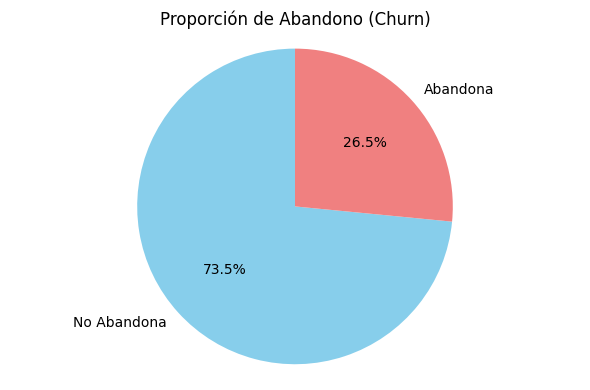

In [ ]:
abandono_counts = y.value_counts(normalize=True)

plt.figure(figsize=(6, 4))

plt.pie(
    abandono_counts,
    labels=['No Abandona', 'Abandona'],
    colors=['skyblue', 'lightcoral'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporción de Abandono (Churn)')
plt.axis('equal')  # Hace que el círculo no se vea ovalado
plt.tight_layout()

plt.show()


In [ ]:
oversampling = SMOTE()
X_balanceada,y_balanceada = oversampling.fit_resample(X,y)

In [ ]:
y_balanceada.value_counts(normalize=True)


,proportion
Abandono,
0,0.5
1,0.5


**Analisis de correlacion**

Visualiza la matriz de correlación para identificar relaciones entre varias variables numericas.

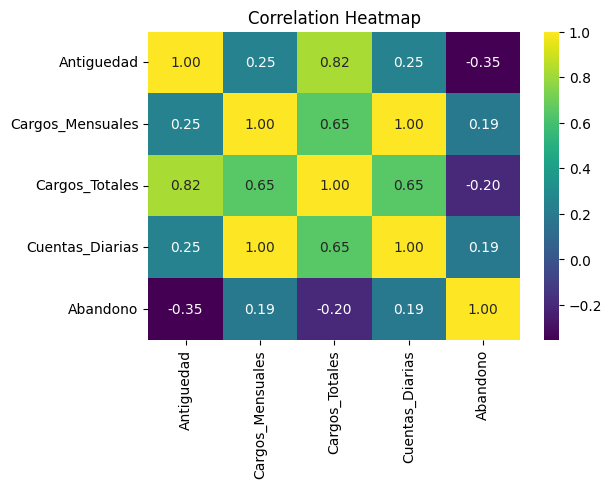

In [ ]:
# Seleccionar columnas numéricas
cols = ['Antiguedad','Cargos_Mensuales','Cargos_Totales','Cuentas_Diarias']

# Unir la variable objetivo con las variables numéricas
df_corr = X[cols].copy()
df_corr['Abandono'] = y

# Calcular matriz de correlación
corr = df_corr.corr()

# Crear gráfico
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis')

plt.title('Correlation Heatmap')
plt.show()

**Variables con mayor correlacion con abandono**
    
 Antiguedad vs Abandono = -0,35 representando esto una correlacion moderada.

Esta variable es un fuerte candidato predictivo para el modelo.

Cargos_Totales vs abandono = -0,20 representa una correlacion negativa debil.

Cargos_Mensuales o Cuentas_Diarias vs Abandono = 0,19 representando una correlacion positiva debil.

Cargos_Mensuales vs Cargos_Diarios = 1 representa una correlacion perfecta.

Carhos_Totales vs Antiguedad = 0,83 representa una correlacion alta positiva.

**Analisis Dirigido**

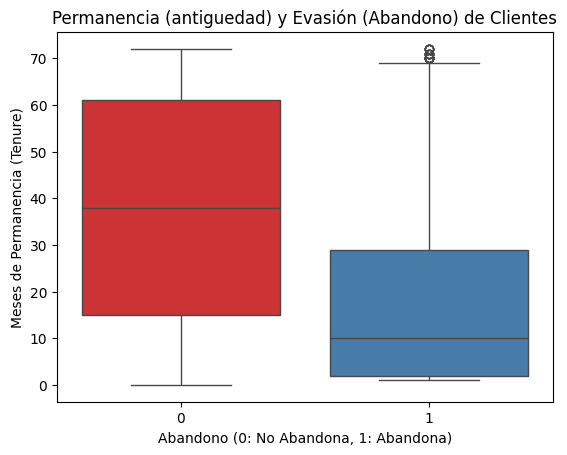

In [ ]:
sns.boxplot(x='Abandono', y='Antiguedad', data=datos, palette='Set1', hue='Abandono', legend=False)

plt.title("Permanencia (antiguedad) y Evasión (Abandono) de Clientes")
plt.xlabel('Abandono (0: No Abandona, 1: Abandona)')
plt.ylabel('Meses de Permanencia (Tenure)')

plt.show()

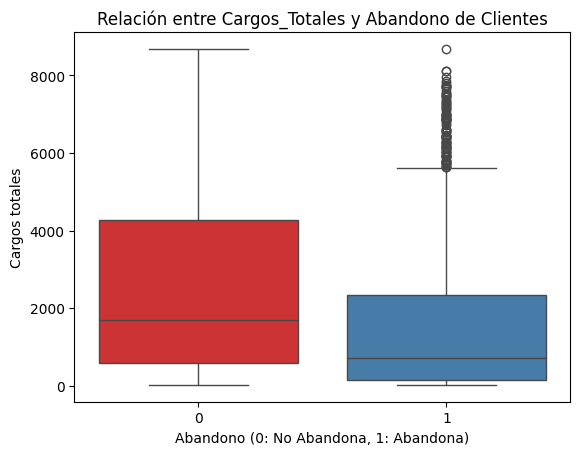

In [ ]:
sns.boxplot(x='Abandono', y='Cargos_Totales', data=datos, palette='Set1', hue='Abandono', legend=False)

plt.title("Relación entre Cargos_Totales y Abandono de Clientes")
plt.xlabel('Abandono (0: No Abandona, 1: Abandona)')
plt.ylabel('Cargos totales')

plt.show()

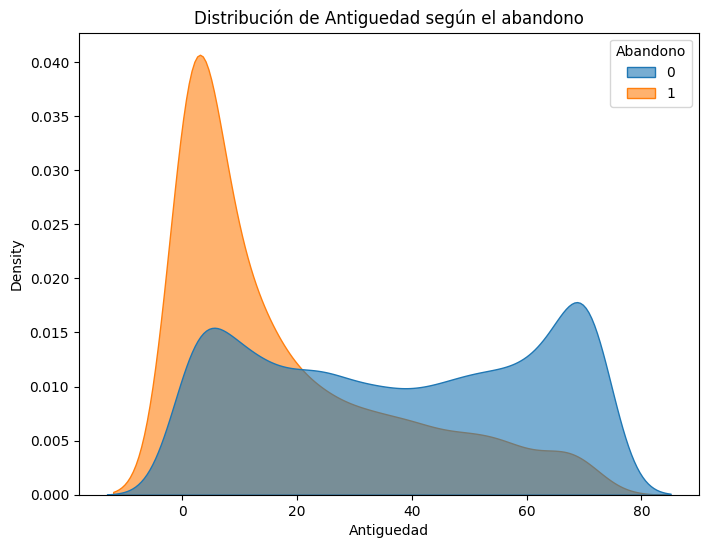

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=datos,
    x="Antiguedad",
    hue="Abandono",
    fill=True,
    common_norm=False,
    alpha=0.6
)

plt.title("Distribución de Antiguedad según el abandono")
plt.show()

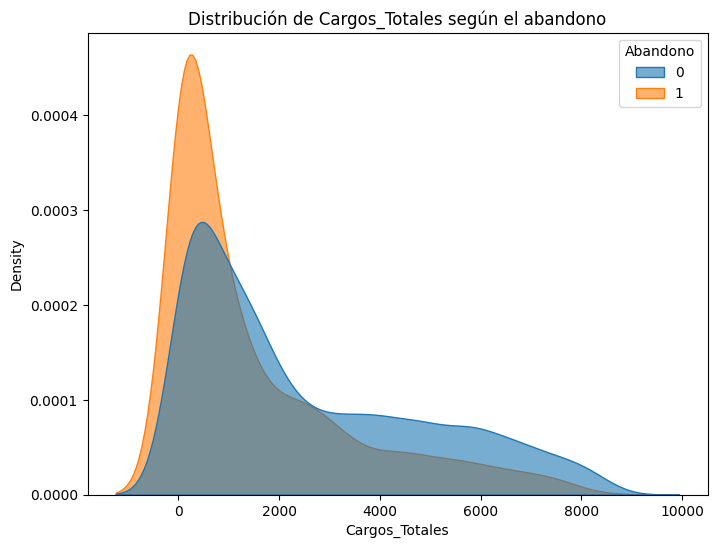

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=datos,
    x="Cargos_Totales",
    hue="Abandono",
    fill=True,
    common_norm=False,
    alpha=0.6
)

plt.title("Distribución de Cargos_Totales según el abandono")
plt.show()

**Modelos Predictivos**

In [ ]:
#Divicion de los datos en conjunto de entrenamiento, validacion y prueba
X_temp,x_test,y_temp,y_test = train_test_split(X_balanceada,y_balanceada,test_size=0.2, random_state=13)
x_train,x_val,y_train,y_val = train_test_split(X_temp,y_temp,random_state=13)

In [ ]:
def mostrar_metricas_clasificacion(y_true, y_pred, titulo_matriz='Matriz de Confusión'):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Métricas de Clasificación:")
    print(f"  Exactitud (Accuracy): {accuracy:.4f}")
    print(f"  Precisión:            {precision:.4f}")
    print(f"  Recall:               {recall:.4f}")
    print(f"  F1-score:             {f1:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(titulo_matriz)
    plt.show()


**Modelo RandomForestRegressor**

In [ ]:

modelo_1 = RandomForestRegressor(max_depth=5,random_state=13)
modelo_1.fit(x_train,y_train)


RandomForestRegressor(max_depth=5, random_state=13)

In [ ]:
y_previst_continuous = modelo_1.predict(x_val)
y_previst = (y_previst_continuous > 0.5).astype(int)

Métricas de Clasificación:
  Exactitud (Accuracy): 0.8237
  Precisión:            0.8246
  Recall:               0.8270
  F1-score:             0.8258


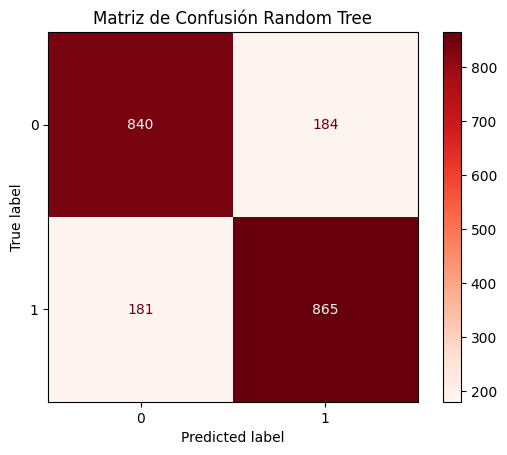

In [ ]:
mostrar_metricas_clasificacion(y_val,y_previst,'Matriz de Confusión Random Tree')

**Modelo Calificador de K vecinos mas cercano (KNeighborsClassifier)**

In [ ]:
normalizacion = MinMaxScaler()
x_train_normalizado = normalizacion.fit_transform(x_train)

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(x_train_normalizado,y_train)

KNeighborsClassifier()

In [ ]:
x_test_normalizado = normalizacion.transform(x_test)

In [ ]:
knn.score(x_test_normalizado,y_test)

0.77487922705314

Métricas de Clasificación:
  Exactitud (Accuracy): 0.7749
  Precisión:            0.7125
  Recall:               0.8938
  F1-score:             0.7929


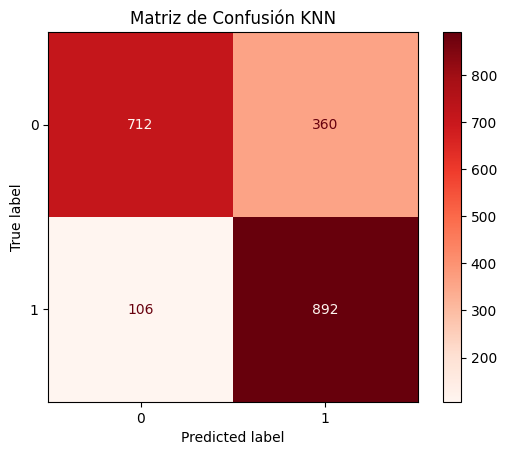

In [ ]:
y_previst_knn = knn.predict(x_test_normalizado)
mostrar_metricas_clasificacion(y_test, y_previst_knn, 'Matriz de Confusión KNN')

In [ ]:
import pandas as pd

# 1. Definimos los datos extraídos de tus capturas
data = {
    'Métrica': ['Exactitud (Accuracy)', 'Precisión', 'Recall (Sensibilidad)', 'F1-score'],
    'KNN': [0.7728, 0.7074, 0.8988, 0.7917],
    'Random Tree': [0.8329, 0.8193, 0.8585, 0.8385]
}

# 2. Creamos el DataFrame
df_comparativo = pd.DataFrame(data)

# 3. Añadimos la lógica para determinar el ganador de cada métrica
def determinar_ganador(row):
    if row['KNN'] > row['Random Tree']:
        return 'KNN'
    else:
        return 'Random Tree'

df_comparativo['Ganador'] = df_comparativo.apply(determinar_ganador, axis=1)

# 4. Mostramos la tabla resultante
print("Tabla Comparativa de Métricas:")
display(df_comparativo)

Tabla Comparativa de Métricas:


,Métrica,KNN,Random Tree,Ganador
0,Exactitud (Accuracy),0.7728,0.8329,Random Tree
1,Precisión,0.7074,0.8193,Random Tree
2,Recall (Sensibilidad),0.8988,0.8585,KNN
3,F1-score,0.7917,0.8385,Random Tree


**Analisis entre RandomForestRegressor vs KNN**

1. Rendimiento General (Ganador: Random Tree)
El modelo Random Tree es superior en casi todos los aspectos fundamentales. Tiene una exactitud notablemente mayor (83.3% vs 77.3%), lo que significa que, en términos generales, acierta más veces que el KNN.

2. Calidad de las Predicciones (Precisión)
El Random Tree es mucho más "confiable" cuando predice la clase positiva. Con una precisión de 0.8193, comete menos errores de tipo "Falso Positivo" (predecir algo que no es). El KNN, con 0.7074, tiene una tendencia mucho mayor a equivocarse al asignar etiquetas positivas (ver los 371 errores en su matriz vs los 198 del Random Tree).

3. Capacidad de Detección (Recall)
Aquí es donde el KNN destaca (0.8988). Si tu objetivo principal es no dejar pasar ningún caso positivo (aunque eso signifique tener algunos falsos positivos), el KNN es ligeramente mejor capturando la clase 1. Sin embargo, el Random Tree no se queda atrás con un sólido 0.8585.

4. Equilibrio (F1-Score)
El F1-score es la métrica de desempate por excelencia. Al ser mayor en el Random Tree (0.8385), nos indica que este modelo logra un balance mucho más saludable y robusto entre precisión y recall que el KNN.

**Importancia de las variables**

In [ ]:
# Crea, ordena y muestra las 10 mejores del modelo RandomForest
feature_importances = pd.DataFrame({
    'Features': X.columns,
    'Importances': (modelo_1.feature_importances_ * 100).round(2)
}).sort_values(by='Importances', ascending=False).head(10)

print(feature_importances)

                         Features  Importances
4         Contrato_Month-to-month        60.92
9    Metodo_Pago_Electronic check        19.15
2   Servicio_Internet_Fiber optic         4.69
14                     Antiguedad         3.89
17               Seguridad_Online         2.35
23        Facturacion_Electronica         2.17
24               Cargos_Mensuales         1.36
5               Contrato_One year         0.91
6               Contrato_Two year         0.87
25                 Cargos_Totales         0.69


In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(knn, x_test_normalizado, y_test, n_repeats=10, random_state=13)

# Get the mean importance of each feature
feature_importances_knn = pd.DataFrame({
    'Features': X.columns,
    'Importances': perm_importance.importances_mean
}).sort_values('Importances', ascending=False)

display(feature_importances_knn.head(10))

,Features,Importances
0,Genero_Male,0.016860
14,Antiguedad,0.015024
9,Metodo_Pago_Electronic check,0.014155
4,Contrato_Month-to-month,0.013623
10,Metodo_Pago_Mailed check,0.012850
6,Contrato_Two year,0.011546
23,Facturacion_Electronica,0.010870
17,Seguridad_Online,0.010676
8,Metodo_Pago_Credit card (automatic),0.010193
5,Contrato_One year,0.009758


**Informe de analisis de abandono de cliente**

-Para el estudio del abandono de los clientes se utilizaron dos modelos RandomFores y KNN.

-En este ananalis de estos dos modelos resulto el mas eficiente para predecir el abandono de los clientes fue el modelode RandonForest.

-El RandomForest es el modelo superior debido a su mayor Exactitud (0.8329) y un F1-score (0.8385) más equilibrado, lo que demuestra una mayor robustez general.

-Aunque el KNN tiene un Recall ligeramente más alto, el RandomForest ofrece una Precisión significativamente mejor (0.8193 frente a 0.7074), cometiendo muchos menos falsos positivos.

-En conclusión, su capacidad para clasificar correctamente ambas clases con menor error lo convierte en la opción más fiable para este conjunto de datos.



**Las variables mas influyente segun el modelo RandomForest**





-Contrato Mes a Mes: posee el factor mas determinante, los clientes con contrato mensual son mas sencibles a abandonar el servicio.

-Pago con cheque electronico : este es otro factores que estan fuertemente relacionado con el abandono del servicio.

-Servicio de Internet Fibra Optica : este es otro factor que esta relacionado con el abandono.

-Antiguedad( contrato): los cliente con menor antiguedad tienden a abandonar mas.

***

**Las variables mas influyente segun el modelo KNN**

-Genero: es un facotr importante.

-Antiguedad (Contrato) : los clientes con menor antiguedad tienden a abandonar mas.

-Metodo de pago electronico : tambien esta relacionado con el abandono del servicio.



